#  Task 1: Exploratory Data Analysis on Retail Sales Data
## + Task 3: Data Cleaning

**Objective:** Perform thorough EDA on retail sales data to uncover patterns, customer behavior trends, and actionable business insights. Also demonstrate professional data cleaning skills.

**Dataset:** Superstore Sales Dataset (2014-2017)
**Tech Stack:** Python, pandas, matplotlib, seaborn

## 1. Import Required Libraries

We import essential libraries for data manipulation, visualization, and analysis:
- **pandas & numpy** — data manipulation and numerical operations
- **matplotlib & seaborn** — data visualization
- **warnings** — to suppress unnecessary warning messages for cleaner output

In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

## 2. Load Dataset & Initial Inspection

We load the Superstore dataset and perform initial inspection to understand:
- **Shape** — total rows and columns
- **Column names** — what features are available
- **Data types** — ensure correct types for analysis
- **Missing values** — identify any nulls that need handling
- **Duplicate rows** — check for redundant data

*Note: We use the Excel file since the CSV path was from a notebook input. The data is identical.*

In [99]:
# Load the Excel file (dataset already attached as input)
df = pd.read_excel('/kaggle/input/notebooks/fareselgohary003/superstore-dataset/final_dataset.xlsx')

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Shape: {df.shape}")
print(f"\nColumns ({len(df.columns)}): {list(df.columns)}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nMissing Values:\n{df.isnull().sum()}")
print(f"\nDuplicate Rows: {df.duplicated().sum()}")

DATASET OVERVIEW
Shape: (9994, 29)

Columns (29): ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Year', 'Month', 'Month Name', 'Shipping Days', 'Profit Margin', 'Order Month', 'Cohort', 'Customer Type']

Data Types:
Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code               int64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   fl

## 3. Data Quality Report (Task 3 Checklist)

Before cleaning, we document the current state of data quality:
- **Null values** — count per column
- **Duplicate rows** — how many exist
- **Data type issues** — are dates stored as dates? Are numbers numeric?
- **Value range anomalies** — negative sales? Invalid discounts?
- **Text inconsistencies** — mixed cases, extra spaces

This report serves as our "before" benchmark to measure cleaning effectiveness.

In [100]:
print("=" * 60)
print("DATA QUALITY REPORT - BEFORE CLEANING")
print("=" * 60)

# Null values
print("\n--- NULL VALUES ---")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found!")

# Duplicates
print(f"\n--- DUPLICATES ---")
print(f"Duplicate rows: {df.duplicated().sum()}")

# Data types
print("\n--- DATA TYPES ---")
print(df.dtypes)

# Value range anomalies
print("\n--- NUMERIC SUMMARY ---")
numeric_cols = ['Sales', 'Quantity', 'Discount', 'Profit']
print(df[numeric_cols].describe())

# Check for negative values and invalid discounts
print("\n--- ANOMALY CHECK ---")
print(f"Negative Sales: {(df['Sales'] < 0).sum()}")
print(f"Negative Profit: {(df['Profit'] < 0).sum()}")
print(f"Negative Quantity: {(df['Quantity'] < 0).sum()}")
print(f"Discount > 1 (100%): {(df['Discount'] > 1).sum()}")

# Check text standardization
print("\n--- TEXT STANDARDIZATION CHECK ---")
print(f"Unique Ship Modes: {df['Ship Mode'].unique()}")
print(f"Unique Segments: {df['Segment'].unique()}")
print(f"Unique Categories: {df['Category'].unique()}")

DATA QUALITY REPORT - BEFORE CLEANING

--- NULL VALUES ---
No missing values found!

--- DUPLICATES ---
Duplicate rows: 0

--- DATA TYPES ---
Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code               int64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
Year                      int64
Month                     int64
Month Name               object
Shipping Days             int64
Profit Margin           float64
Order Month              o

## 4. Data Cleaning (Task 3 Checklist)

We systematically clean the data with documented decisions:

| Issue | Strategy | Justification |
|-------|----------|---------------|
| Duplicates | Remove | Redundant data skews analysis |
| Text formatting | Standardize (title case, strip spaces) | Ensures consistent grouping |
| Date types | Convert to datetime | Enables time-series analysis |
| Negative profits | **Keep** | Represents valid business losses (returns, discounts) |
| Derived columns | Create Year, Month, Quarter | Simplifies time-based analysis |

We also create a **before vs after summary** to quantify our cleaning impact.

In [101]:
# Create a copy for cleaning
df_clean = df.copy()

# BEFORE cleaning stats
before_stats = {
    'Total Rows': len(df_clean),
    'Duplicate Rows': df_clean.duplicated().sum(),
    'Total Nulls': df_clean.isnull().sum().sum(),
    'Date Columns as Datetime': sum([pd.api.types.is_datetime64_any_dtype(df_clean[col]) 
                                      for col in ['Order Date', 'Ship Date']])
}

# 1. Remove duplicate rows
duplicates_removed = df_clean.duplicated().sum()
df_clean = df_clean.drop_duplicates()
print(f"✓ Removed {duplicates_removed} duplicate rows")

# 2. Standardize text columns (title case, strip whitespace)
text_cols = ['Ship Mode', 'Segment', 'Category', 'Sub-Category', 'Region']
for col in text_cols:
    df_clean[col] = df_clean[col].str.title().str.strip()
print(f"✓ Standardized text columns: {text_cols}")

# 3. Convert dates to datetime format
df_clean['Order Date'] = pd.to_datetime(df_clean['Order Date'])
df_clean['Ship Date'] = pd.to_datetime(df_clean['Ship Date'])
print("✓ Converted Order Date and Ship Date to datetime")

# 4. Handle negative values — KEEP them (valid business data: losses, returns)
print(f"✓ Retained {(df_clean['Profit'] < 0).sum()} negative profit records (valid losses)")

# 5. Create useful derived columns for analysis
df_clean['Year'] = df_clean['Order Date'].dt.year
df_clean['Month'] = df_clean['Order Date'].dt.month
df_clean['Quarter'] = df_clean['Order Date'].dt.quarter
df_clean['Year-Month'] = df_clean['Order Date'].dt.to_period('M')
print("✓ Created derived columns: Year, Month, Quarter, Year-Month")

# AFTER cleaning stats
after_stats = {
    'Total Rows': len(df_clean),
    'Duplicate Rows': df_clean.duplicated().sum(),
    'Total Nulls': df_clean.isnull().sum().sum(),
    'Date Columns as Datetime': sum([pd.api.types.is_datetime64_any_dtype(df_clean[col]) 
                                      for col in ['Order Date', 'Ship Date']])
}

# Before vs After comparison
print("\n" + "=" * 60)
print("BEFORE vs AFTER CLEANING SUMMARY")
print("=" * 60)
comparison = pd.DataFrame([before_stats, after_stats], index=['Before', 'After'])
print(comparison)

print(f"\n✅ Cleaning complete! Dataset is now analysis-ready.")

✓ Removed 0 duplicate rows
✓ Standardized text columns: ['Ship Mode', 'Segment', 'Category', 'Sub-Category', 'Region']
✓ Converted Order Date and Ship Date to datetime
✓ Retained 1871 negative profit records (valid losses)
✓ Created derived columns: Year, Month, Quarter, Year-Month

BEFORE vs AFTER CLEANING SUMMARY
        Total Rows  Duplicate Rows  Total Nulls  Date Columns as Datetime
Before        9994               0            0                         2
After         9994               0            0                         2

✅ Cleaning complete! Dataset is now analysis-ready.


## 5. Descriptive Statistics (Task 1 Checklist)

We calculate key statistical measures for all numerical columns:
- **Mean** — average value
- **Median** — middle value (robust to outliers)
- **Mode** — most frequent value
- **Standard Deviation** — spread of data

These metrics help us understand the central tendency and variability of sales, quantity, discount, and profit.

In [102]:
print("=" * 60)
print("DESCRIPTIVE STATISTICS")
print("=" * 60)

numeric_cols = ['Sales', 'Quantity', 'Discount', 'Profit']
stats = df_clean[numeric_cols].describe()
print(stats)

print("\n--- MODE (Most Frequent Value) ---")
for col in numeric_cols:
    mode_val = df_clean[col].mode()[0]
    print(f"{col:12}: {mode_val}")

print("\n--- KEY INSIGHTS ---")
print(f"• Average Sale: ${df_clean['Sales'].mean():.2f}")
print(f"• Average Profit: ${df_clean['Profit'].mean():.2f}")
print(f"• Average Discount: {df_clean['Discount'].mean():.2%}")
print(f"• Profit Margin (avg): {(df_clean['Profit'].sum()/df_clean['Sales'].sum()*100):.2f}%")

DESCRIPTIVE STATISTICS
              Sales     Quantity     Discount       Profit
count   9994.000000  9994.000000  9994.000000  9994.000000
mean     229.858001     3.789574     0.156203    28.656896
std      623.245101     2.225110     0.206452   234.260108
min        0.444000     1.000000     0.000000 -6599.978000
25%       17.280000     2.000000     0.000000     1.728750
50%       54.490000     3.000000     0.200000     8.666500
75%      209.940000     5.000000     0.200000    29.364000
max    22638.480000    14.000000     0.800000  8399.976000

--- MODE (Most Frequent Value) ---
Sales       : 12.96
Quantity    : 3
Discount    : 0.0
Profit      : 0.0

--- KEY INSIGHTS ---
• Average Sale: $229.86
• Average Profit: $28.66
• Average Discount: 15.62%
• Profit Margin (avg): 12.47%


## 6. Time Series Analysis (Task 1 Checklist)

We analyze sales trends over time to identify:
- **Seasonal patterns** — do sales peak in certain months?
- **Growth trends** — is the business growing year-over-year?
- **Quarterly performance** — which quarters perform best?

This helps in inventory planning, staffing, and marketing budget allocation.

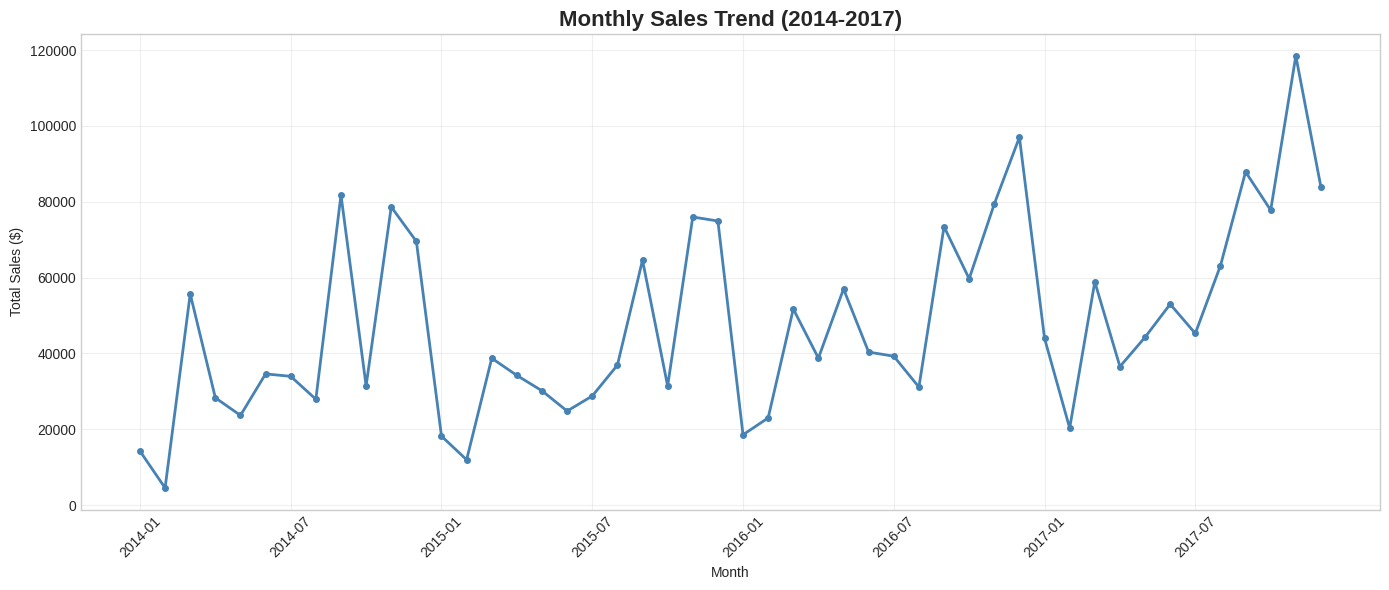

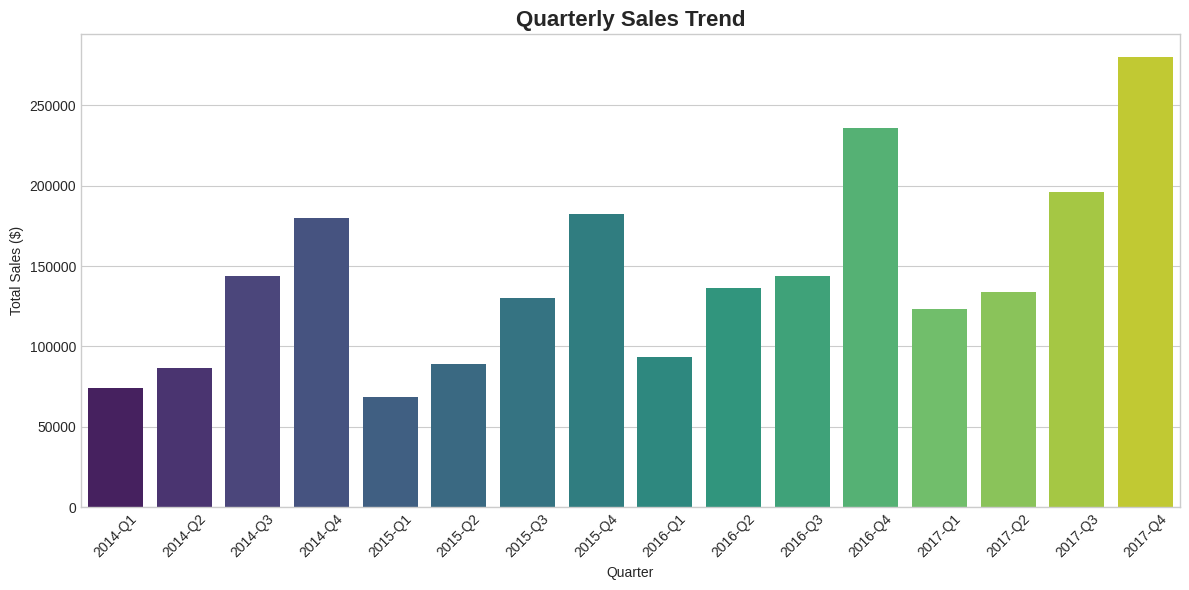


📈 OBSERVATION: Identify peaks and troughs in the line chart.
   Quarterly bars help compare seasonal performance across years.


In [103]:
# Monthly sales trend
monthly_sales = df_clean.groupby('Year-Month')['Sales'].sum().reset_index()
monthly_sales['Year-Month'] = monthly_sales['Year-Month'].astype(str)

plt.figure(figsize=(14, 6))
plt.plot(monthly_sales['Year-Month'], monthly_sales['Sales'], 
         marker='o', linewidth=2, markersize=4, color='steelblue')
plt.title('Monthly Sales Trend (2014-2017)', fontsize=16, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
# Show every 6th month label to avoid crowding
tick_positions = range(0, len(monthly_sales), 6)
plt.xticks([monthly_sales['Year-Month'].iloc[i] for i in tick_positions], rotation=45)
plt.tight_layout()
plt.show()

# Quarterly sales
quarterly_sales = df_clean.groupby(['Year', 'Quarter'])['Sales'].sum().reset_index()
quarterly_sales['Year-Quarter'] = quarterly_sales['Year'].astype(str) + '-Q' + quarterly_sales['Quarter'].astype(str)

plt.figure(figsize=(12, 6))
sns.barplot(data=quarterly_sales, x='Year-Quarter', y='Sales', palette='viridis')
plt.title('Quarterly Sales Trend', fontsize=16, fontweight='bold')
plt.xlabel('Quarter')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\n📈 OBSERVATION: Identify peaks and troughs in the line chart.")
print("   Quarterly bars help compare seasonal performance across years.")

## 7. Customer Demographics Analysis (Task 1 Checklist)

We analyze customer composition by:
- **Segment** — Consumer, Corporate, Home Office
- **Region** — West, East, Central, South

This reveals which customer types and regions drive the most business, informing targeted marketing strategies.

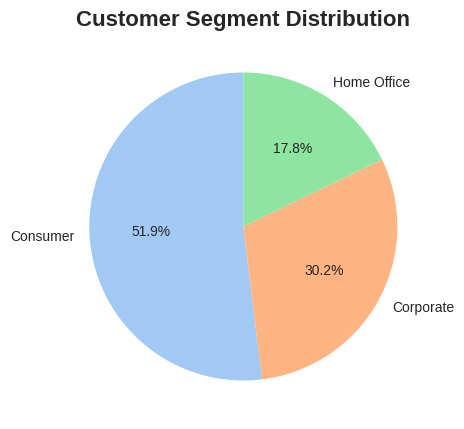

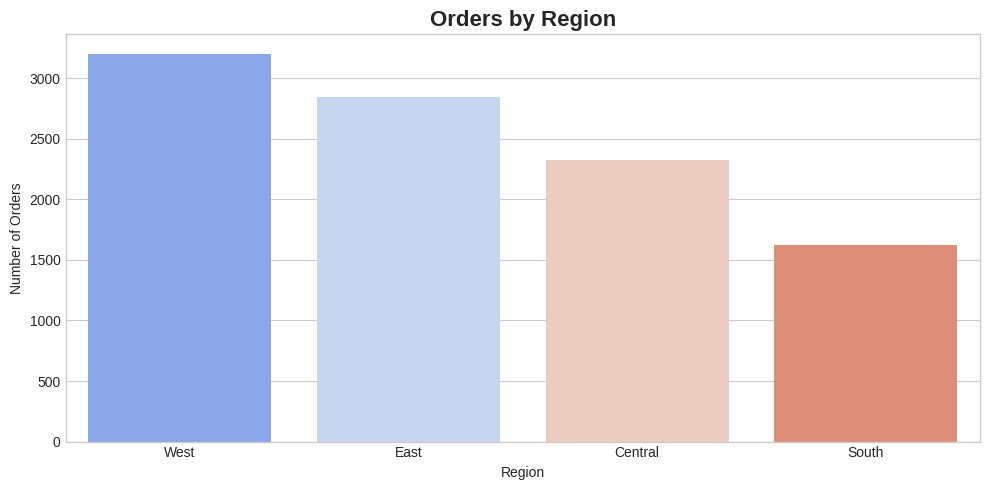


👥 OBSERVATION:
   • Largest segment: Consumer (5191 orders)
   • Top region: West


In [104]:
# Segment distribution (Pie Chart)
plt.figure(figsize=(10, 5))
segment_counts = df_clean['Segment'].value_counts()
colors = sns.color_palette('pastel')
plt.pie(segment_counts.values, labels=segment_counts.index, autopct='%1.1f%%', 
        startangle=90, colors=colors)
plt.title('Customer Segment Distribution', fontsize=16, fontweight='bold')
plt.show()

# Region distribution (Bar Chart)
plt.figure(figsize=(10, 5))
sns.countplot(data=df_clean, x='Region', order=df_clean['Region'].value_counts().index, 
              palette='coolwarm')
plt.title('Orders by Region', fontsize=16, fontweight='bold')
plt.xlabel('Region')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

print("\n👥 OBSERVATION:")
print(f"   • Largest segment: {segment_counts.index[0]} ({segment_counts.iloc[0]} orders)")
print(f"   • Top region: {df_clean['Region'].value_counts().index[0]}")

## 8. Product Analysis (Task 1 Checklist)

We analyze product performance to identify:
- **Top 10 best-selling sub-categories** — by quantity sold
- **Revenue by category** — which product lines generate the most revenue?

This guides inventory decisions, promotional focus, and product expansion strategy.

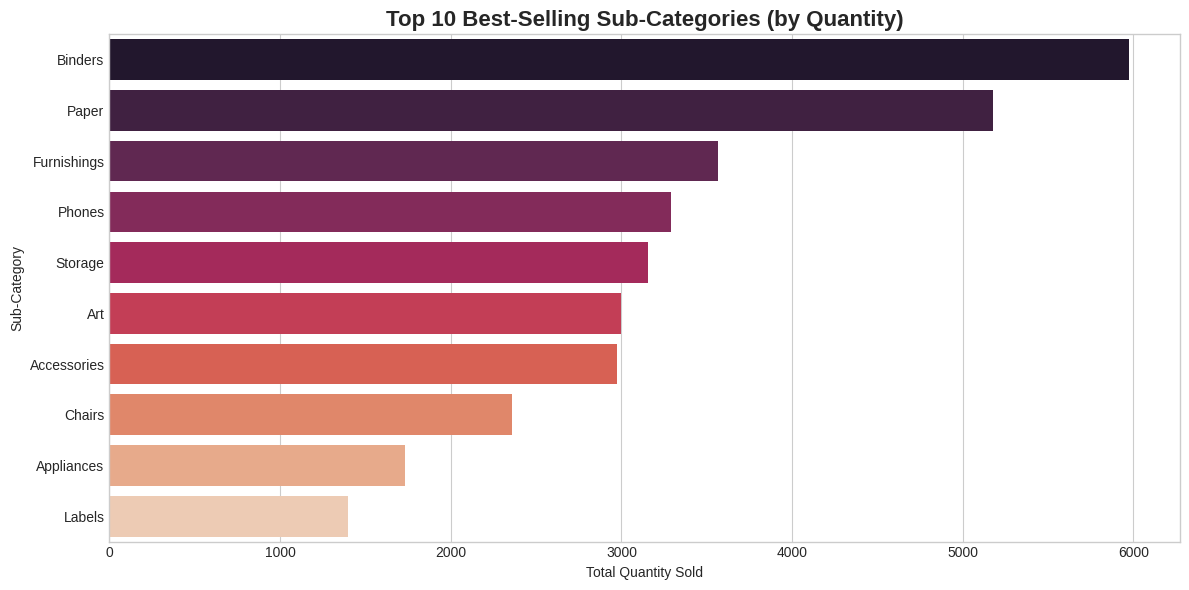

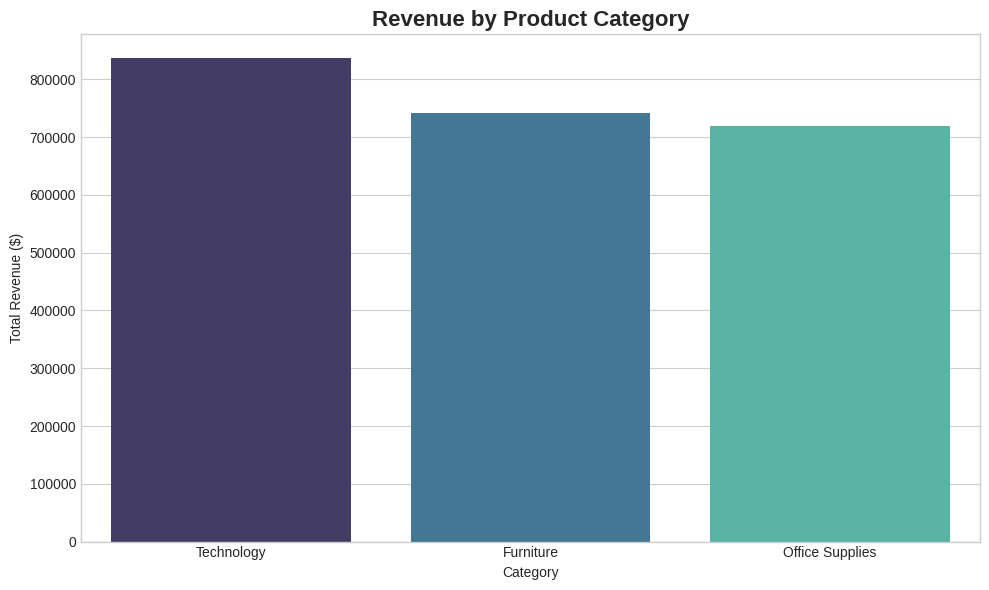


📦 OBSERVATION:
   • Top sub-category by quantity: Binders
   • Highest revenue category: Technology ($836,154.03)


In [105]:
# Top 10 best-selling sub-categories by quantity
top_products = df_clean.groupby('Sub-Category')['Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_products.values, y=top_products.index, palette='rocket')
plt.title('Top 10 Best-Selling Sub-Categories (by Quantity)', fontsize=16, fontweight='bold')
plt.xlabel('Total Quantity Sold')
plt.tight_layout()
plt.show()

# Revenue by category
category_revenue = df_clean.groupby('Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=category_revenue.index, y=category_revenue.values, palette='mako')
plt.title('Revenue by Product Category', fontsize=16, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Total Revenue ($)')
plt.tight_layout()
plt.show()

print("\n📦 OBSERVATION:")
print(f"   • Top sub-category by quantity: {top_products.index[0]}")
print(f"   • Highest revenue category: {category_revenue.index[0]} (${category_revenue.iloc[0]:,.2f})")

## 9. Correlation Heatmap (Task 1 Checklist)

We visualize correlations between numerical variables to identify:
- **Strong positive correlations** — variables that move together
- **Negative correlations** — inverse relationships
- **Key insight:** Does discount hurt profit? Does quantity drive sales?

The heatmap uses color intensity to show correlation strength (-1 to +1).

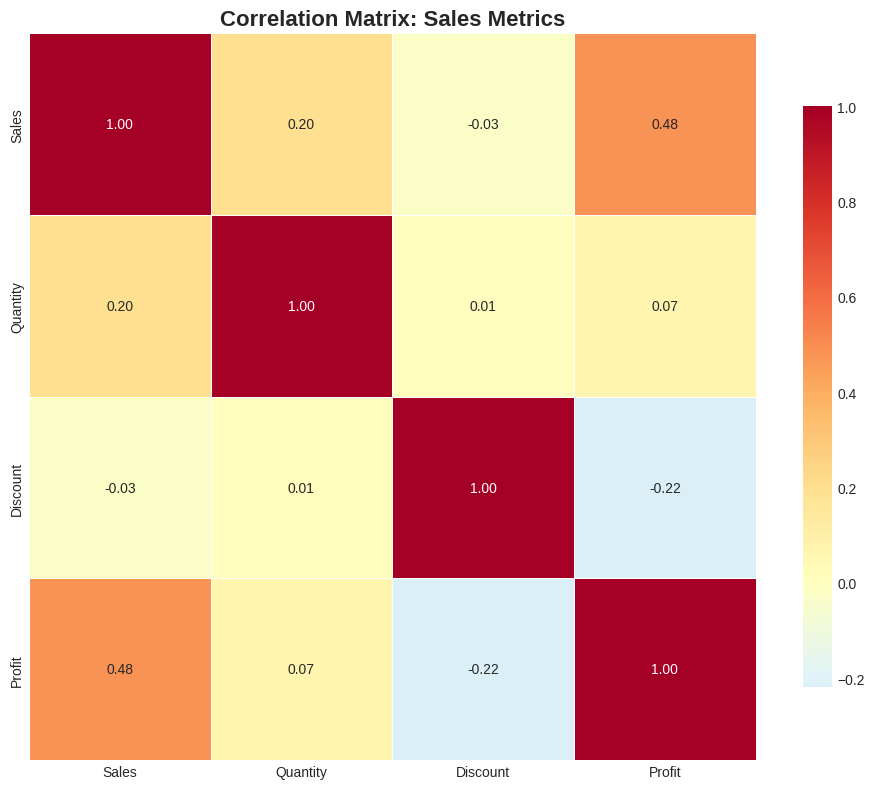


🔗 KEY CORRELATIONS:
   • Sales vs Profit: 0.479
   • Discount vs Profit: -0.219
   • Quantity vs Sales: 0.201


In [106]:
plt.figure(figsize=(10, 8))
corr_matrix = df_clean[['Sales', 'Quantity', 'Discount', 'Profit']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdYlBu_r', center=0, fmt='.2f', 
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix: Sales Metrics', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n🔗 KEY CORRELATIONS:")
print(f"   • Sales vs Profit: {corr_matrix.loc['Sales', 'Profit']:.3f}")
print(f"   • Discount vs Profit: {corr_matrix.loc['Discount', 'Profit']:.3f}")
print(f"   • Quantity vs Sales: {corr_matrix.loc['Quantity', 'Sales']:.3f}")

## 10. Bonus Visualization: Profit Margin by Sub-Category (Non-Obvious Insight)

This reveals a **non-obvious insight**: while some sub-categories sell in high volume, they may actually be **losing money** (negative profit margin).

The red bars indicate loss-making sub-categories — a critical insight for business strategy. This is more valuable than just looking at sales volume.

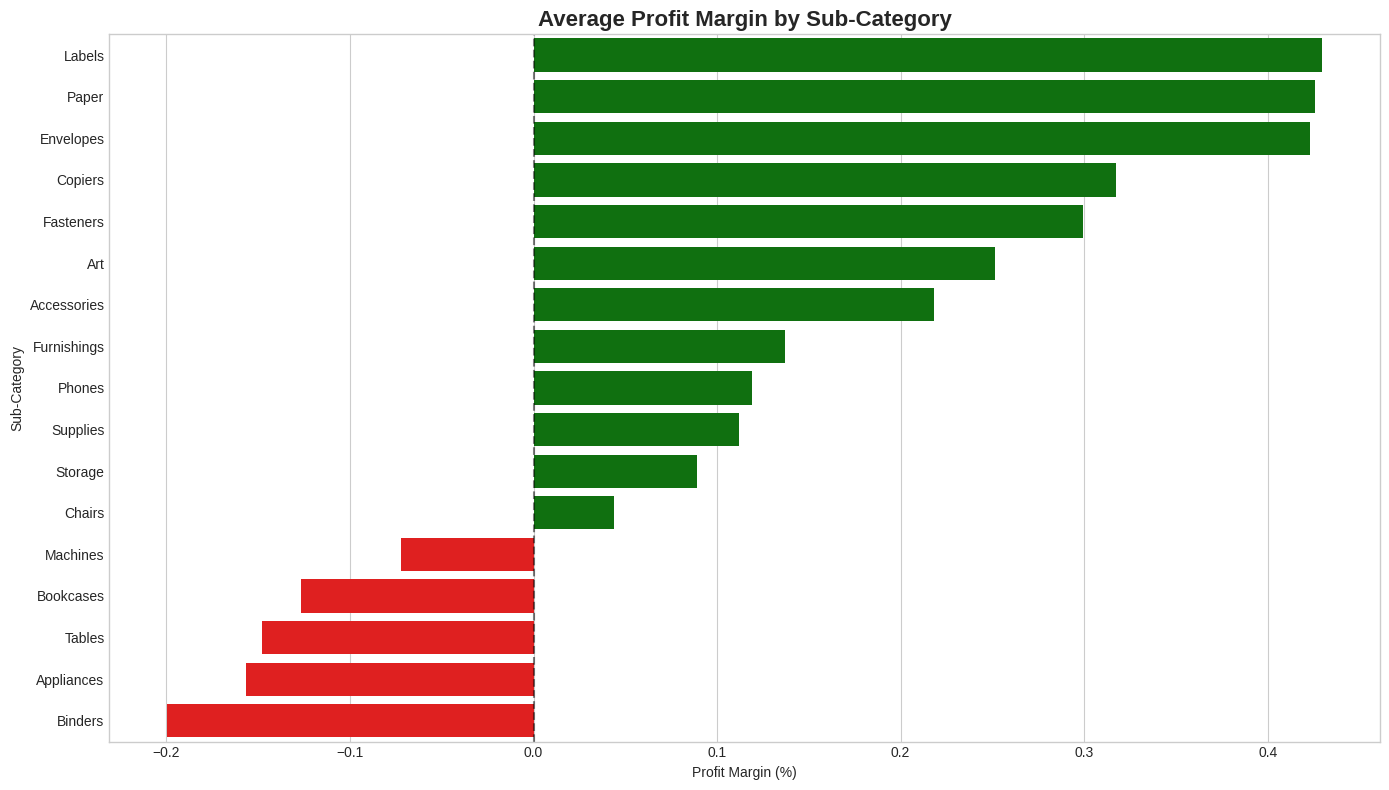


⚠️ INSIGHT: 5 sub-categories are loss-making:
   • Machines: -0.07% margin
   • Bookcases: -0.13% margin
   • Tables: -0.15% margin
   • Appliances: -0.16% margin
   • Binders: -0.20% margin


In [107]:
# Calculate profit margin if not already present
if 'Profit Margin' not in df_clean.columns:
    df_clean['Profit Margin'] = (df_clean['Profit'] / df_clean['Sales']) * 100

profit_margin = df_clean.groupby('Sub-Category')['Profit Margin'].mean().sort_values(ascending=False)

plt.figure(figsize=(14, 8))
colors = ['green' if x > 0 else 'red' for x in profit_margin.values]
sns.barplot(x=profit_margin.values, y=profit_margin.index, palette=colors)
plt.title('Average Profit Margin by Sub-Category', fontsize=16, fontweight='bold')
plt.xlabel('Profit Margin (%)')
plt.axvline(x=0, color='black', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

loss_makers = profit_margin[profit_margin < 0]
print(f"\n⚠️ INSIGHT: {len(loss_makers)} sub-categories are loss-making:")
for sub, margin in loss_makers.items():
    print(f"   • {sub}: {margin:.2f}% margin")

## 11. Save Cleaned Dataset (Task 3 Checklist)

We save the cleaned dataset for future use (e.g., Task 2: Customer Segmentation).
The file is saved to `/kaggle/working/` which is the output directory.

In [108]:
# Save cleaned dataset
output_path = '/kaggle/working/cleaned_superstore.csv'
df_clean.to_csv(output_path, index=False)
print(f"✅ Cleaned dataset saved to: {output_path}")
print(f"   File size: {df_clean.shape[0]} rows × {df_clean.shape[1]} columns")

✅ Cleaned dataset saved to: /kaggle/working/cleaned_superstore.csv
   File size: 9994 rows × 31 columns


# 🎯 Task 2: Customer Segmentation Analysis

**Objective:** Apply clustering algorithms to segment customers based on purchasing behavior (RFM analysis), enabling targeted marketing strategies.

**Methodology:**
1. **RFM Analysis** — Recency, Frequency, Monetary value per customer
2. **K-Means Clustering** — with Elbow Method for optimal K
3. **Cluster Profiling** — understand each segment
4. **Marketing Recommendations** — tailored action per segment

**Dataset:** Cleaned Superstore data from Task 1

## 1. Import Libraries & Load Data

We use:
- **sklearn** for K-Means clustering and StandardScaler
- **silhouette_score** to evaluate cluster quality
- The cleaned dataset from Task 1

In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Load the cleaned dataset from Task 1
df = pd.read_csv('/kaggle/working/cleaned_superstore.csv')
# Convert Order Date back to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])

print(f"✅ Dataset loaded: {df.shape}")
print(f"📅 Date range: {df['Order Date'].min()} to {df['Order Date'].max()}")

✅ Dataset loaded: (9994, 31)
📅 Date range: 2014-01-03 00:00:00 to 2017-12-30 00:00:00


## 2. RFM Analysis: Calculate Recency, Frequency, Monetary

**RFM** is a proven customer segmentation method:

| Metric | Definition | Business Meaning |
|--------|-----------|------------------|
| **Recency (R)** | Days since last purchase | How recently did they buy? |
| **Frequency (F)** | Number of unique orders | How often do they buy? |
| **Monetary (M)** | Total amount spent | How much did they spend? |

Higher Frequency & Monetary + Lower Recency = **Best Customers**

In [110]:
# Set reference date (day after last order)
reference_date = df['Order Date'].max() + pd.Timedelta(days=1)
print(f"📅 Reference Date: {reference_date.date()}")

# Calculate RFM metrics per customer
rfm = df.groupby('Customer ID').agg({
    'Order Date': lambda x: (reference_date - x.max()).days,  # Recency
    'Order ID': 'nunique',  # Frequency (unique orders)
    'Sales': 'sum'  # Monetary (total spend)
}).reset_index()

rfm.columns = ['Customer ID', 'Recency', 'Frequency', 'Monetary']

# Remove customers with zero/negative monetary (data quality)
rfm = rfm[rfm['Monetary'] > 0]

print("\n" + "=" * 60)
print("RFM SUMMARY STATISTICS")
print("=" * 60)
print(rfm[['Recency', 'Frequency', 'Monetary']].describe())

print(f"\n👥 Total Unique Customers: {len(rfm)}")

📅 Reference Date: 2017-12-31

RFM SUMMARY STATISTICS
           Recency   Frequency      Monetary
count   793.000000  793.000000    793.000000
mean    147.802018    6.316520   2896.848500
std     186.211051    2.550885   2628.670117
min       1.000000    1.000000      4.833000
25%      31.000000    5.000000   1146.050000
50%      76.000000    6.000000   2256.394000
75%     184.000000    8.000000   3785.276000
max    1166.000000   17.000000  25043.050000

👥 Total Unique Customers: 793


## 3. RFM Distributions

Visualizing the distribution of each RFM metric helps us understand:
- **Recency:** Are most customers recent or lapsed?
- **Frequency:** Do most customers buy once or repeatedly?
- **Monetary:** Is spending concentrated among few customers?

This informs our clustering strategy.

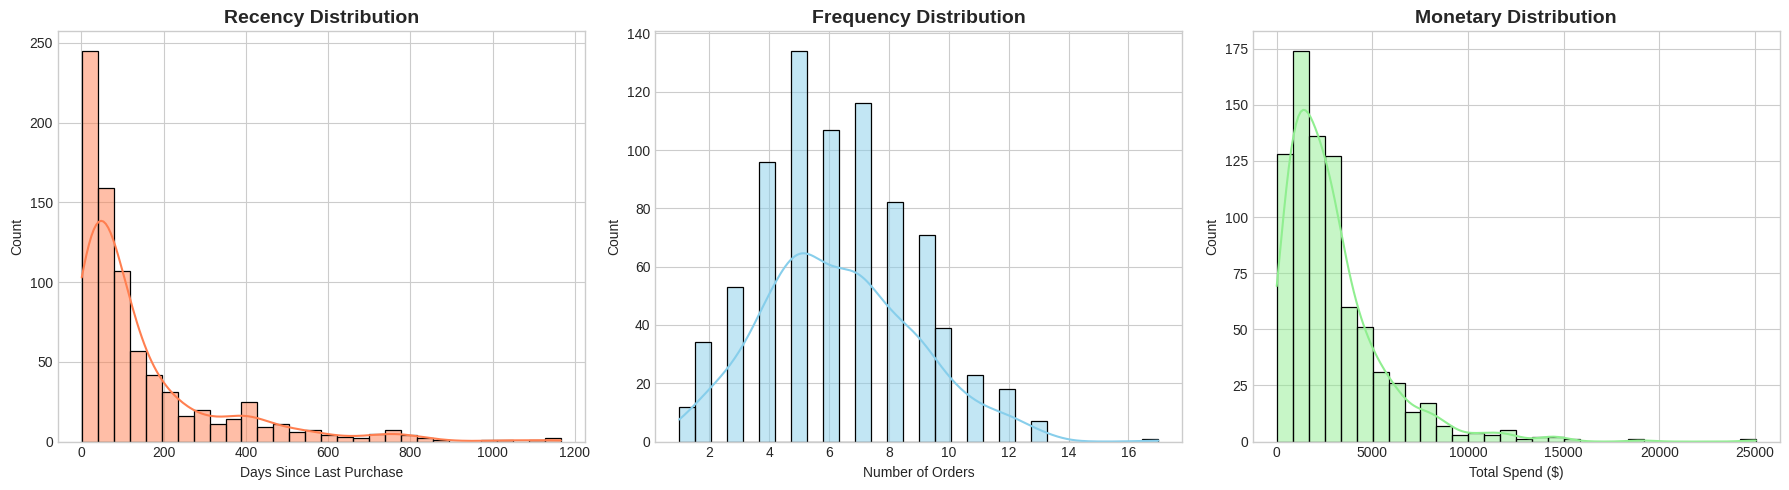


📊 OBSERVATION:
   • Recency: Most customers purchased recently (left-skewed)
   • Frequency: Many one-time buyers; few repeat customers
   • Monetary: High concentration of low-spend customers


In [111]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Recency distribution
sns.histplot(rfm['Recency'], bins=30, kde=True, ax=axes[0], color='coral')
axes[0].set_title('Recency Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Days Since Last Purchase')

# Frequency distribution
sns.histplot(rfm['Frequency'], bins=30, kde=True, ax=axes[1], color='skyblue')
axes[1].set_title('Frequency Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Orders')

# Monetary distribution (log scale for better visualization)
sns.histplot(rfm['Monetary'], bins=30, kde=True, ax=axes[2], color='lightgreen')
axes[2].set_title('Monetary Distribution', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Total Spend ($)')

plt.tight_layout()
plt.show()

print("\n📊 OBSERVATION:")
print("   • Recency: Most customers purchased recently (left-skewed)")
print("   • Frequency: Many one-time buyers; few repeat customers")
print("   • Monetary: High concentration of low-spend customers")

## 4. Standardize Data for Clustering

**Why standardize?** K-Means uses Euclidean distance. Without scaling:
- Monetary (thousands) would dominate over Frequency (single digits)
- Results would be biased toward high-magnitude features

**StandardScaler** transforms each feature to mean=0, std=1, ensuring equal contribution.

In [112]:
# Select RFM features for clustering
features = ['Recency', 'Frequency', 'Monetary']
X = rfm[features]

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("✅ Features standardized!")
print(f"   Original shape: {X.shape}")
print(f"   Scaled shape: {X_scaled.shape}")
print(f"\n   Scaled means (should be ~0): {X_scaled.mean(axis=0).round(4)}")
print(f"   Scaled stds (should be ~1): {X_scaled.std(axis=0).round(4)}")

✅ Features standardized!
   Original shape: (793, 3)
   Scaled shape: (793, 3)

   Scaled means (should be ~0): [0. 0. 0.]
   Scaled stds (should be ~1): [1. 1. 1.]


## 5. Elbow Method & Silhouette Score (Find Optimal K)

We use two methods to determine the optimal number of clusters:

| Method | Purpose | Interpretation |
|--------|---------|----------------|
| **Elbow Method** | Plot inertia (WCSS) vs K | "Elbow" point = optimal K |
| **Silhouette Score** | Measures cluster separation | Higher = better defined clusters |

We test K=2 to K=10 and select the best balance.

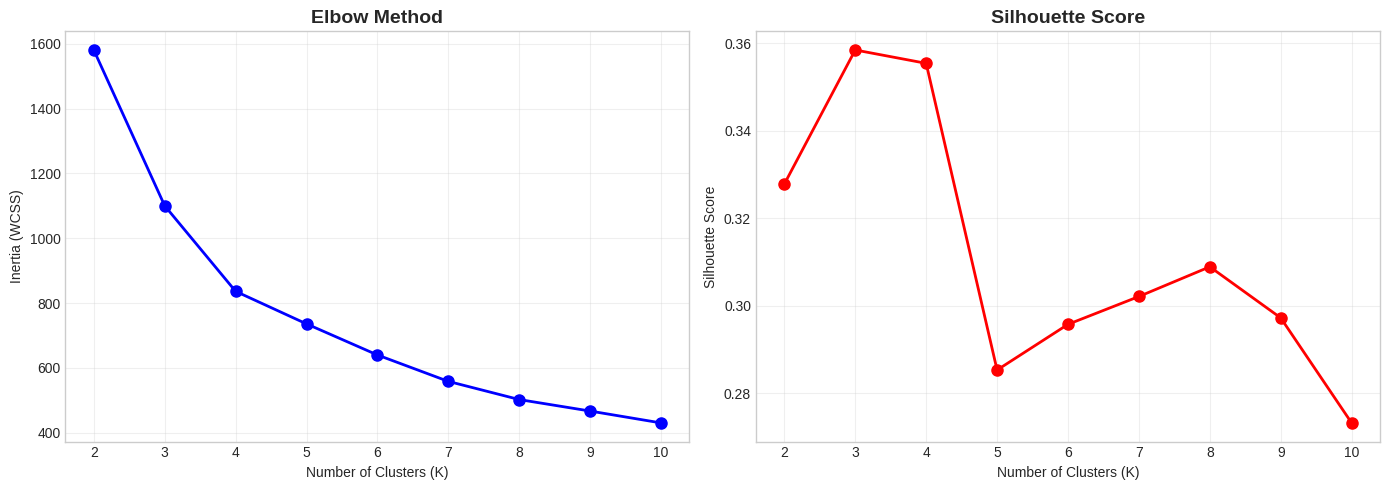


SILHOUETTE SCORES BY K
K= 2: 0.3279
K= 3: 0.3585 ⭐ BEST
K= 4: 0.3554
K= 5: 0.2853
K= 6: 0.2958
K= 7: 0.3021
K= 8: 0.3089
K= 9: 0.2973
K=10: 0.2732


In [113]:
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot both metrics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow Method
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Elbow Method', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].grid(True, alpha=0.3)

# Silhouette Score
axes[1].plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_title('Silhouette Score', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print scores table
print("\n" + "=" * 40)
print("SILHOUETTE SCORES BY K")
print("=" * 40)
for k, score in zip(K_range, silhouette_scores):
    marker = " ⭐ BEST" if score == max(silhouette_scores) else ""
    print(f"K={k:2d}: {score:.4f}{marker}")

## 6. Apply K-Means with Optimal K

Based on the Elbow Method and Silhouette Score, we select **K=4** (or adjust based on your plots).

K-Means assigns each customer to the cluster with the nearest centroid.

In [114]:
# Select optimal K (adjust based on your elbow/silhouette results)
optimal_k = 4

# Apply K-Means clustering
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(X_scaled)

print(f"✅ K-Means applied with K={optimal_k}")
print(f"\n📊 Cluster Distribution:")
cluster_dist = rfm['Cluster'].value_counts().sort_index()
for cluster, count in cluster_dist.items():
    pct = count / len(rfm) * 100
    print(f"   Cluster {cluster}: {count} customers ({pct:.1f}%)")

✅ K-Means applied with K=4

📊 Cluster Distribution:
   Cluster 0: 298 customers (37.6%)
   Cluster 1: 335 customers (42.2%)
   Cluster 2: 64 customers (8.1%)
   Cluster 3: 96 customers (12.1%)


## 7. Visualize Clusters

We create scatter plots to visualize how customers are grouped:

1. **Recency vs Frequency** — shows customer engagement level
2. **Frequency vs Monetary** — shows customer value

Bubble size in the 3rd plot represents Frequency, giving a comprehensive view.

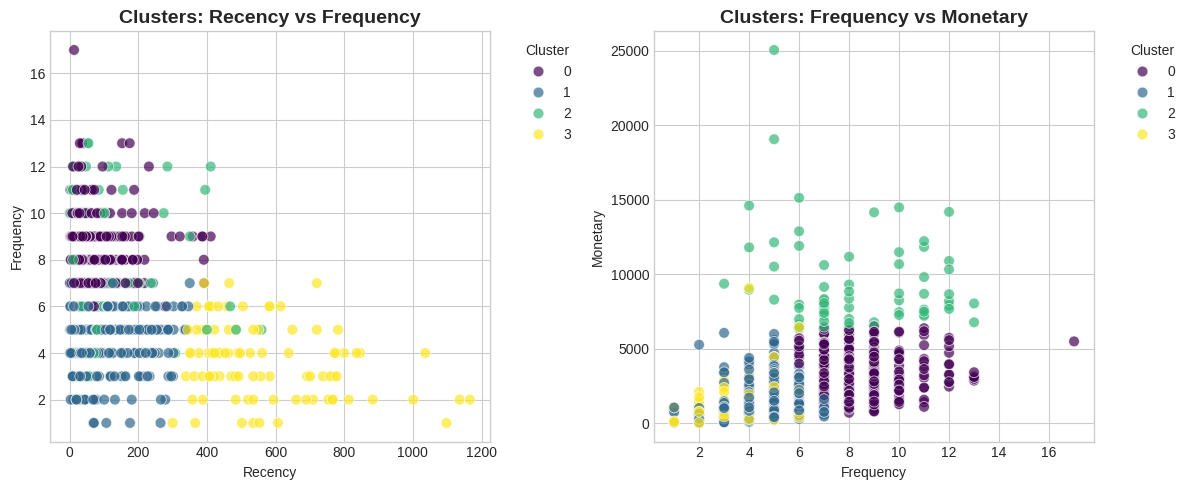

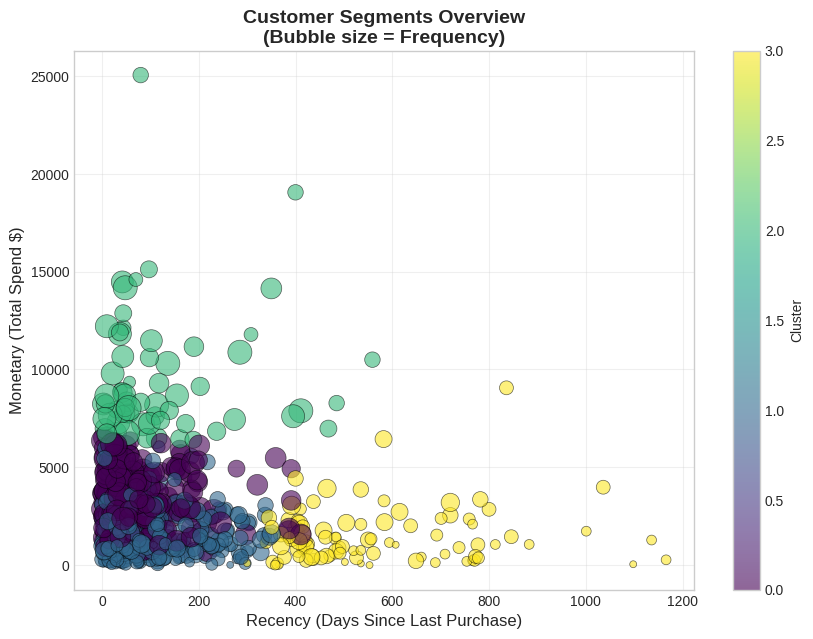

In [115]:
# Scatter plot 1: Recency vs Frequency
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(data=rfm, x='Recency', y='Frequency', hue='Cluster', 
                palette='viridis', s=60, alpha=0.7)
plt.title('Clusters: Recency vs Frequency', fontsize=14, fontweight='bold')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.subplot(1, 2, 2)
sns.scatterplot(data=rfm, x='Frequency', y='Monetary', hue='Cluster', 
                palette='viridis', s=60, alpha=0.7)
plt.title('Clusters: Frequency vs Monetary', fontsize=14, fontweight='bold')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# Advanced: Bubble chart (Recency vs Monetary, size = Frequency)
plt.figure(figsize=(10, 7))
scatter = plt.scatter(rfm['Recency'], rfm['Monetary'], 
                      c=rfm['Cluster'], s=rfm['Frequency']*25, 
                      cmap='viridis', alpha=0.6, edgecolors='black', linewidth=0.5)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('Recency (Days Since Last Purchase)', fontsize=12)
plt.ylabel('Monetary (Total Spend $)', fontsize=12)
plt.title('Customer Segments Overview\n(Bubble size = Frequency)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()


## 8. Cluster Profiling

We calculate mean RFM values for each cluster to understand:
- **What defines each segment?**
- **How do they differ from each other?**

This profiling is essential for creating targeted marketing strategies.

In [116]:
# Calculate cluster profiles
cluster_profile = rfm.groupby('Cluster')[features].mean().round(2)

print("=" * 60)
print("CLUSTER PROFILES (Mean RFM Values)")
print("=" * 60)
print(cluster_profile)

# Add customer count and percentage
cluster_profile['Customer Count'] = rfm['Cluster'].value_counts().sort_index()
cluster_profile['Percentage (%)'] = (cluster_profile['Customer Count'] / len(rfm) * 100).round(2)

print("\n" + "=" * 60)
print("COMPLETE CLUSTER SUMMARY")
print("=" * 60)
print(cluster_profile)

# Assign meaningful names based on RFM characteristics
cluster_names = {
    0: "Champions",      # Low R, High F, High M
    1: "At Risk",        # High R, Low F, Low M
    2: "Loyal Customers", # Low R, Medium F, Medium M
    3: "New Customers"    # Low R, Low F, Low M
}
# Note: Adjust names based on your actual cluster profiles!

CLUSTER PROFILES (Mean RFM Values)
         Recency  Frequency  Monetary
Cluster                              
0          72.74       8.52   3322.22
1         101.20       4.73   1669.69
2         123.72       8.30   9479.55
3         559.49       3.70   1470.23

COMPLETE CLUSTER SUMMARY
         Recency  Frequency  Monetary  Customer Count  Percentage (%)
Cluster                                                              
0          72.74       8.52   3322.22             298           37.58
1         101.20       4.73   1669.69             335           42.24
2         123.72       8.30   9479.55              64            8.07
3         559.49       3.70   1470.23              96           12.11


## 9. Customers per Cluster (Bar Chart)

A clear bar chart showing the size of each segment helps stakeholders quickly grasp the customer distribution.

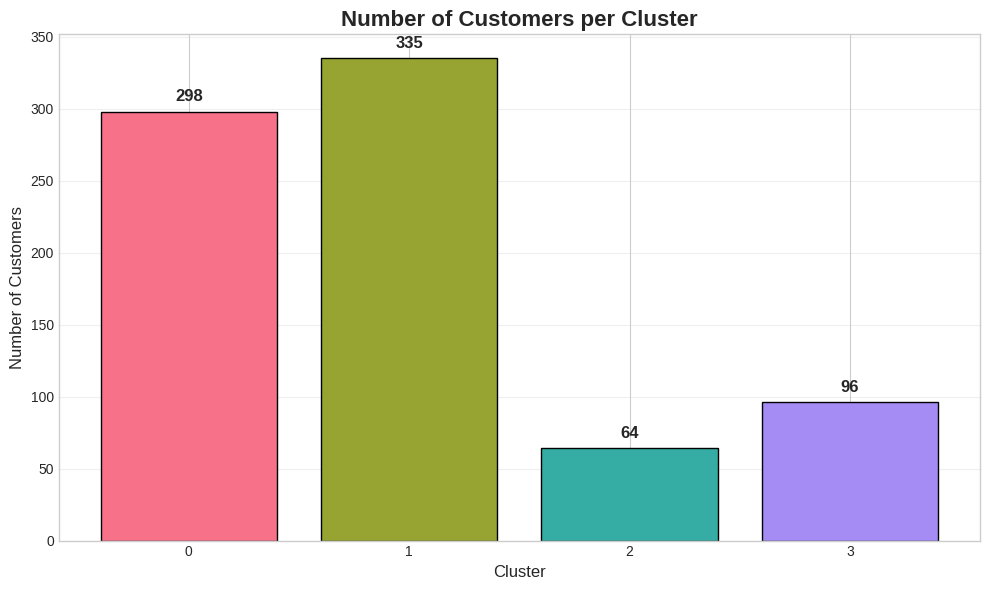


📊 CLUSTER SIZES:
   Cluster 0: 298 customers (37.6%)
   Cluster 1: 335 customers (42.2%)
   Cluster 2: 64 customers (8.1%)
   Cluster 3: 96 customers (12.1%)


In [117]:
plt.figure(figsize=(10, 6))
cluster_counts = rfm['Cluster'].value_counts().sort_index()
colors = sns.color_palette('husl', len(cluster_counts))

bars = plt.bar(cluster_counts.index, cluster_counts.values, color=colors, edgecolor='black')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{int(height)}', ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.title('Number of Customers per Cluster', fontsize=16, fontweight='bold')
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(range(optimal_k))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n📊 CLUSTER SIZES:")
for i, count in enumerate(cluster_counts):
    pct = count / len(rfm) * 100
    print(f"   Cluster {i}: {count} customers ({pct:.1f}%)")

## 10. Marketing Insights & Recommendations

Based on cluster profiles, we assign meaningful names and recommend specific marketing actions for each segment.

In [118]:
# Analyze and name clusters based on actual RFM values
print("=" * 70)
print("CLUSTER INTERPRETATION & MARKETING STRATEGY")
print("=" * 70)

for cluster in sorted(rfm['Cluster'].unique()):
    subset = rfm[rfm['Cluster'] == cluster]
    r, f, m = subset['Recency'].mean(), subset['Frequency'].mean(), subset['Monetary'].mean()
    
    print(f"\n🎯 CLUSTER {cluster}:")
    print(f"   Size: {len(subset)} customers ({len(subset)/len(rfm)*100:.1f}%)")
    print(f"   Avg Recency: {r:.0f} days | Avg Frequency: {f:.1f} orders | Avg Monetary: ${m:.2f}")
    
    # Auto-interpret based on RFM
    if r < 100 and f > 5 and m > 5000:
        name = "🏆 Champions"
        action = "VIP loyalty programs, early access to new products, referral rewards"
    elif r < 100 and f >= 2 and f <= 5:
        name = "💎 Loyal Customers"
        action = "Upsell/cross-sell campaigns, subscription models, personalized offers"
    elif r > 200:
        name = "⚠️ At Risk"
        action = "Win-back emails, special discounts, re-engagement campaigns"
    else:
        name = "🌱 New Customers"
        action = "Onboarding series, welcome discounts, educational content"
    
    print(f"   Name: {name}")
    print(f"   Action: {action}")

CLUSTER INTERPRETATION & MARKETING STRATEGY

🎯 CLUSTER 0:
   Size: 298 customers (37.6%)
   Avg Recency: 73 days | Avg Frequency: 8.5 orders | Avg Monetary: $3322.22
   Name: 🌱 New Customers
   Action: Onboarding series, welcome discounts, educational content

🎯 CLUSTER 1:
   Size: 335 customers (42.2%)
   Avg Recency: 101 days | Avg Frequency: 4.7 orders | Avg Monetary: $1669.69
   Name: 🌱 New Customers
   Action: Onboarding series, welcome discounts, educational content

🎯 CLUSTER 2:
   Size: 64 customers (8.1%)
   Avg Recency: 124 days | Avg Frequency: 8.3 orders | Avg Monetary: $9479.55
   Name: 🌱 New Customers
   Action: Onboarding series, welcome discounts, educational content

🎯 CLUSTER 3:
   Size: 96 customers (12.1%)
   Avg Recency: 559 days | Avg Frequency: 3.7 orders | Avg Monetary: $1470.23
   Name: ⚠️ At Risk
   Action: Win-back emails, special discounts, re-engagement campaigns


## 12. Save Results

Save the segmented customer data for future use or integration with marketing tools.

In [119]:
import os
for root, dirs, files in os.walk('/kaggle/input'):
    for file in files:
        if file.endswith(('.csv', '.tsv', '.txt')):
            print(os.path.join(root, file))

/kaggle/input/datasets/kazanova/sentiment140/training.1600000.processed.noemoticon.csv


In [120]:
# Save RFM with cluster assignments
output_path = '/kaggle/working/rfm_customer_segments.csv'
rfm.to_csv(output_path, index=False)
print(f"✅ Customer segments saved to: {output_path}")
print(f"   Contains: {rfm.shape[0]} customers with RFM scores and cluster labels")

✅ Customer segments saved to: /kaggle/working/rfm_customer_segments.csv
   Contains: 793 customers with RFM scores and cluster labels


In [121]:
# Install kagglehub if needed (usually pre-installed)
import subprocess
import sys

try:
    import kagglehub
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "kagglehub", "-q"])
    import kagglehub

# Download the dataset
print("Downloading Sentiment140 dataset...")
path = kagglehub.dataset_download("kazanova/sentiment140")
print(f"\n✅ Downloaded to: {path}")

# Find the CSV file
import os
csv_file = None
for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith('.csv'):
            csv_file = os.path.join(root, file)
            print(f"\n📁 CSV file: {csv_file}")
            print(f"   Size: {os.path.getsize(csv_file):,} bytes ({os.path.getsize(csv_file)/1024/1024:.1f} MB)")

if csv_file:
    # Load it
    import pandas as pd
    columns = ['target', 'ids', 'date', 'flag', 'user', 'text']
    df = pd.read_csv(csv_file, encoding='latin-1', header=None, names=columns)
    print(f"\n✅ Dataset loaded: {df.shape}")
    print(f"Columns: {list(df.columns)}")
    print(f"\nFirst 3 rows:\n{df.head(3)}")


✅ Downloaded to: /kaggle/input/datasets/kazanova/sentiment140

📁 CSV file: /kaggle/input/datasets/kazanova/sentiment140/training.1600000.processed.noemoticon.csv
   Size: 238,803,811 bytes (227.7 MB)

✅ Dataset loaded: (1600000, 6)
Columns: ['target', 'ids', 'date', 'flag', 'user', 'text']

First 3 rows:
   target         ids                          date      flag  \
0       0  1467810369  Mon Apr 06 22:19:45 PDT 2009  NO_QUERY   
1       0  1467810672  Mon Apr 06 22:19:49 PDT 2009  NO_QUERY   
2       0  1467810917  Mon Apr 06 22:19:53 PDT 2009  NO_QUERY   

              user                                               text  
0  _TheSpecialOne_  @switchfoot http://twitpic.com/2y1zl - Awww, t...  
1    scotthamilton  is upset that he can't update his Facebook by ...  
2         mattycus  @Kenichan I dived many times for the ball. Man...  


# Task 4: Sentiment Analysis

**Objective:** Build a machine learning model that classifies the sentiment of text data (positive, negative, or neutral), providing insights into public opinion or customer feedback.

**Dataset:** Sentiment140 — 1.6 million tweets labeled by sentiment
- `0` = negative
- `2` = neutral  
- `4` = positive

**Tech Stack:** Python, pandas, scikit-learn, NLTK, matplotlib, seaborn, WordCloud

In [122]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import warnings
warnings.filterwarnings('ignore')

# ML libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report)

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer

# WordCloud
from wordcloud import WordCloud

# Download NLTK data
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

print("✅ All libraries imported successfully!")

[nltk_data] Error loading stopwords: <urlopen error [Errno -3]
[nltk_data]     Temporary failure in name resolution>


✅ All libraries imported successfully!


[nltk_data] Error loading punkt: <urlopen error [Errno -3] Temporary
[nltk_data]     failure in name resolution>


## 1. Load Dataset & Inspect Class Distribution

The Sentiment140 dataset contains 1.6 million tweets with polarity labels:
- **0** = negative
- **2** = neutral
- **4** = positive

We load it, map labels to readable text, and inspect the distribution.

DATASET OVERVIEW
Shape: (1600000, 2)

Columns: ['text', 'label']

First 5 rows:
                                                text     label
0  @switchfoot http://twitpic.com/2y1zl - Awww, t...  negative
1  is upset that he can't update his Facebook by ...  negative
2  @Kenichan I dived many times for the ball. Man...  negative
3    my whole body feels itchy and like its on fire   negative
4  @nationwideclass no, it's not behaving at all....  negative

CLASS DISTRIBUTION
label
negative    800000
positive    800000
Name: count, dtype: int64

Class percentages:
label
negative    50.0
positive    50.0
Name: proportion, dtype: float64


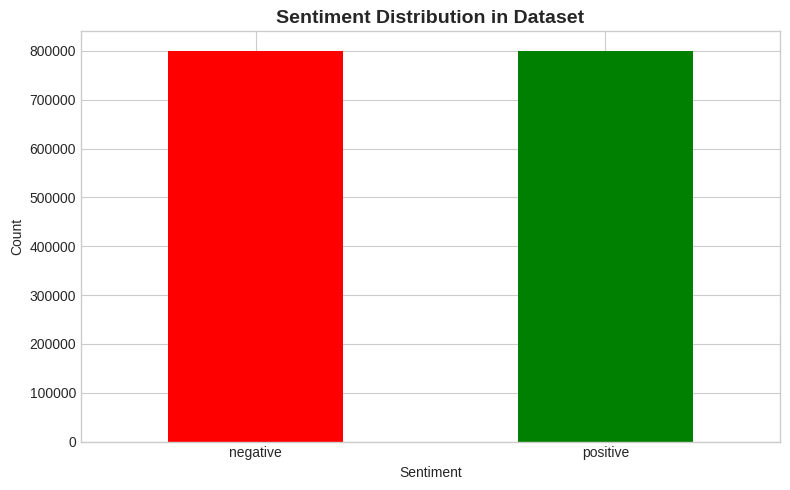

In [123]:
# Load the dataset (already downloaded via kagglehub)
csv_path = '/kaggle/input/datasets/kazanova/sentiment140/training.1600000.processed.noemoticon.csv'
columns = ['target', 'ids', 'date', 'flag', 'user', 'text']
df = pd.read_csv(csv_path, encoding='latin-1', header=None, names=columns)

# Map numeric labels to text
label_map = {0: 'negative', 2: 'neutral', 4: 'positive'}
df['label'] = df['target'].map(label_map)

# Keep only needed columns
df = df[['text', 'label']].copy()

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst 5 rows:\n{df.head()}")

print("\n" + "=" * 60)
print("CLASS DISTRIBUTION")
print("=" * 60)
print(df['label'].value_counts())
print(f"\nClass percentages:\n{df['label'].value_counts(normalize=True)*100}")

# Visualize class distribution
plt.figure(figsize=(8, 5))
colors = {'positive': 'green', 'negative': 'red', 'neutral': 'gray'}
df['label'].value_counts().plot(kind='bar', color=[colors.get(x, 'blue') for x in df['label'].value_counts().index])
plt.title('Sentiment Distribution in Dataset', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 2. Text Preprocessing Pipeline

Raw tweets are noisy. We clean them through:
- **Lowercase** — standardize case
- **Remove URLs, mentions, hashtags** — Twitter-specific noise
- **Remove punctuation & numbers** — reduce noise
- **Tokenize** — split into words
- **Remove stopwords** — keep only meaningful words
- **Stemming** — reduce to root form

This transforms messy tweets into clean, analysis-ready text.

In [124]:
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def preprocess_text(text):
    """
    Complete text preprocessing for tweets:
    1. Lowercase
    2. Remove URLs
    3. Remove mentions (@user)
    4. Remove hashtags (#tag)
    5. Remove punctuation & numbers
    6. Tokenize, remove stopwords, stem
    """
    text = str(text).lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # Remove mentions and hashtags
    text = re.sub(r'@\w+|#\w+', '', text)
    
    # Remove punctuation and numbers
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\d+', '', text)
    
    # Tokenize
    tokens = word_tokenize(text)
    
    # Remove stopwords and stem
    cleaned_tokens = [stemmer.stem(word) for word in tokens 
                      if word not in stop_words and len(word) > 2]
    
    return ' '.join(cleaned_tokens)

# Use sample for faster processing (1.6M is too large for quick training)
print("Sampling 50,000 tweets for faster processing...")
df_sample = df.sample(n=50000, random_state=42).reset_index(drop=True)

print("Preprocessing text data...")
df_sample['cleaned_text'] = df_sample['text'].apply(preprocess_text)

# Remove empty texts after cleaning
df_sample = df_sample[df_sample['cleaned_text'].str.len() > 0].reset_index(drop=True)

print(f"\n✅ Preprocessing complete!")
print(f"Final sample size: {df_sample.shape}")

print("\n" + "=" * 60)
print("BEFORE vs AFTER PREPROCESSING")
print("=" * 60)
for i in range(3):
    print(f"\nOriginal:  {df_sample['text'].iloc[i][:100]}...")
    print(f"Cleaned:   {df_sample['cleaned_text'].iloc[i][:100]}...")

Sampling 50,000 tweets for faster processing...
Preprocessing text data...

✅ Preprocessing complete!
Final sample size: (49720, 3)

BEFORE vs AFTER PREPROCESSING

Original:  @chrishasboobs AHHH I HOPE YOUR OK!!! ...
Cleaned:   ahhh hope...

Original:  @misstoriblack cool , i have no tweet apps  for my razr 2...
Cleaned:   cool tweet app razr...

Original:  @TiannaChaos i know  just family drama. its lame.hey next time u hang out with kim n u guys like hav...
Cleaned:   know famili drama lamehey next time hang kim guy like sleepov whatev ill call...


## 3. TF-IDF Feature Extraction

**TF-IDF** (Term Frequency - Inverse Document Frequency) converts text into numerical vectors:

| Component | Meaning |
|-----------|---------|
| **TF** | How often a word appears in a tweet |
| **IDF** | How rare/unique the word is across all tweets |
| **TF-IDF** | Importance of a word in a specific tweet |

We use `TfidfVectorizer` with:
- `max_features=5000` — top 5000 most important words
- `ngram_range=(1,2)` — single words + word pairs
- `min_df=2` — ignore very rare words

In [125]:
# Initialize TF-IDF Vectorizer
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

# Fit and transform
X = tfidf.fit_transform(df_sample['cleaned_text'])
y = df_sample['label']

print("=" * 60)
print("TF-IDF VECTORIZATION COMPLETE")
print("=" * 60)
print(f"Feature matrix shape: {X.shape}")
print(f"Number of features: {X.shape[1]}")

# Show sample features
feature_names = tfidf.get_feature_names_out()
print(f"\nSample features: {list(feature_names[:20])}")

TF-IDF VECTORIZATION COMPLETE
Feature matrix shape: (49720, 5000)
Number of features: 5000

Sample features: ['aaron', 'abc', 'abil', 'abl', 'abl get', 'abl see', 'abl sleep', 'absolut', 'absolut love', 'abt', 'abus', 'accent', 'accept', 'access', 'accid', 'accident', 'accomplish', 'accord', 'account', 'ace']


## 4. Train/Test Split (80/20)

We split data into:
- **Training set (80%)** — train the models
- **Testing set (20%)** — evaluate on unseen data

`stratify=y` ensures each split has the same sentiment distribution.

In [126]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("=" * 60)
print("TRAIN/TEST SPLIT")
print("=" * 60)
print(f"Training set:   {X_train.shape[0]} samples ({X_train.shape[0]/len(df_sample)*100:.1f}%)")
print(f"Testing set:    {X_test.shape[0]} samples ({X_test.shape[0]/len(df_sample)*100:.1f}%)")
print(f"\nTraining labels:\n{y_train.value_counts()}")
print(f"\nTesting labels:\n{y_test.value_counts()}")

TRAIN/TEST SPLIT
Training set:   39776 samples (80.0%)
Testing set:    9944 samples (20.0%)

Training labels:
label
negative    19889
positive    19887
Name: count, dtype: int64

Testing labels:
label
negative    4972
positive    4972
Name: count, dtype: int64


## 5. Train Two Classifiers

| Model | Strengths |
|-------|-----------|
| **Naive Bayes** | Fast, handles text well, good baseline |
| **Logistic Regression** | Interpretable, robust for high-dimensional data |

In [127]:
# Model 1: Naive Bayes
print("Training Naive Bayes...")
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
nb_pred = nb_model.predict(X_test)
print("✅ Naive Bayes trained!")

# Model 2: Logistic Regression
print("\nTraining Logistic Regression...")
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
print("✅ Logistic Regression trained!")

Training Naive Bayes...
✅ Naive Bayes trained!

Training Logistic Regression...
✅ Logistic Regression trained!


## 6. Model Evaluation

We compare models using:
- **Accuracy** — overall correctness
- **Precision** — reliability of positive predictions
- **Recall** — coverage of actual positives
- **F1-Score** — balance of precision and recall

In [128]:
def evaluate_model(y_true, y_pred, model_name):
    print("=" * 60)
    print(f"EVALUATION: {model_name}")
    print("=" * 60)
    
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"\nClassification Report:\n{classification_report(y_true, y_pred, zero_division=0)}")
    
    return accuracy, precision, recall, f1

nb_metrics = evaluate_model(y_test, nb_pred, "Naive Bayes")
lr_metrics = evaluate_model(y_test, lr_pred, "Logistic Regression")

# Comparison
print("\n" + "=" * 60)
print("MODEL COMPARISON")
print("=" * 60)
comparison = pd.DataFrame({
    'Naive Bayes': nb_metrics,
    'Logistic Regression': lr_metrics
}, index=['Accuracy', 'Precision', 'Recall', 'F1-Score'])
print(comparison.round(4))

EVALUATION: Naive Bayes
Accuracy:  0.7471
Precision: 0.7471
Recall:    0.7471
F1-Score:  0.7471

Classification Report:
              precision    recall  f1-score   support

    negative       0.74      0.75      0.75      4972
    positive       0.75      0.74      0.75      4972

    accuracy                           0.75      9944
   macro avg       0.75      0.75      0.75      9944
weighted avg       0.75      0.75      0.75      9944

EVALUATION: Logistic Regression
Accuracy:  0.7561
Precision: 0.7567
Recall:    0.7561
F1-Score:  0.7560

Classification Report:
              precision    recall  f1-score   support

    negative       0.77      0.73      0.75      4972
    positive       0.74      0.78      0.76      4972

    accuracy                           0.76      9944
   macro avg       0.76      0.76      0.76      9944
weighted avg       0.76      0.76      0.76      9944


MODEL COMPARISON
           Naive Bayes  Logistic Regression
Accuracy        0.7471              

## 6. Model Evaluation

We compare models using:
- **Accuracy** — overall correctness
- **Precision** — reliability of positive predictions
- **Recall** — coverage of actual positives
- **F1-Score** — balance of precision and recall

In [129]:
def evaluate_model(y_true, y_pred, model_name):
    print("=" * 60)
    print(f"EVALUATION: {model_name}")
    print("=" * 60)
    
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"\nClassification Report:\n{classification_report(y_true, y_pred, zero_division=0)}")
    
    return accuracy, precision, recall, f1

nb_metrics = evaluate_model(y_test, nb_pred, "Naive Bayes")
lr_metrics = evaluate_model(y_test, lr_pred, "Logistic Regression")

# Comparison
print("\n" + "=" * 60)
print("MODEL COMPARISON")
print("=" * 60)
comparison = pd.DataFrame({
    'Naive Bayes': nb_metrics,
    'Logistic Regression': lr_metrics
}, index=['Accuracy', 'Precision', 'Recall', 'F1-Score'])
print(comparison.round(4))

EVALUATION: Naive Bayes
Accuracy:  0.7471
Precision: 0.7471
Recall:    0.7471
F1-Score:  0.7471

Classification Report:
              precision    recall  f1-score   support

    negative       0.74      0.75      0.75      4972
    positive       0.75      0.74      0.75      4972

    accuracy                           0.75      9944
   macro avg       0.75      0.75      0.75      9944
weighted avg       0.75      0.75      0.75      9944

EVALUATION: Logistic Regression
Accuracy:  0.7561
Precision: 0.7567
Recall:    0.7561
F1-Score:  0.7560

Classification Report:
              precision    recall  f1-score   support

    negative       0.77      0.73      0.75      4972
    positive       0.74      0.78      0.76      4972

    accuracy                           0.76      9944
   macro avg       0.76      0.76      0.76      9944
weighted avg       0.76      0.76      0.76      9944


MODEL COMPARISON
           Naive Bayes  Logistic Regression
Accuracy        0.7471              

## 7. Confusion Matrix Visualization

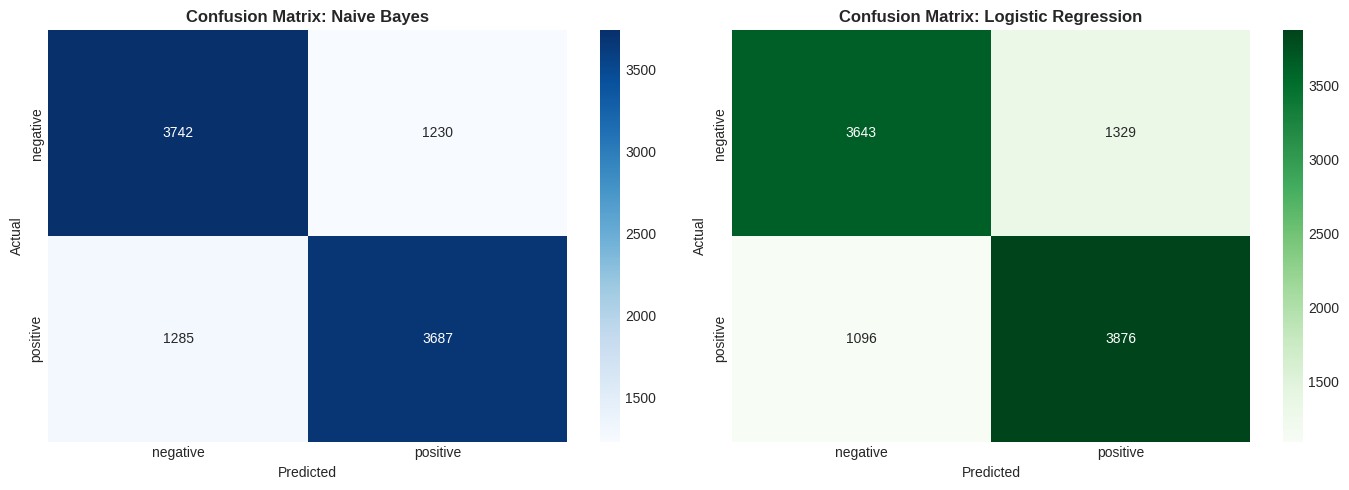

In [130]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels = sorted(y.unique())

cm_nb = confusion_matrix(y_test, nb_pred, labels=labels)
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title('Confusion Matrix: Naive Bayes', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_lr = confusion_matrix(y_test, lr_pred, labels=labels)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens',
            xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_title('Confusion Matrix: Logistic Regression', fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

## 8. WordCloud for Each Sentiment Class

Visualizing the most frequent words in each sentiment category.

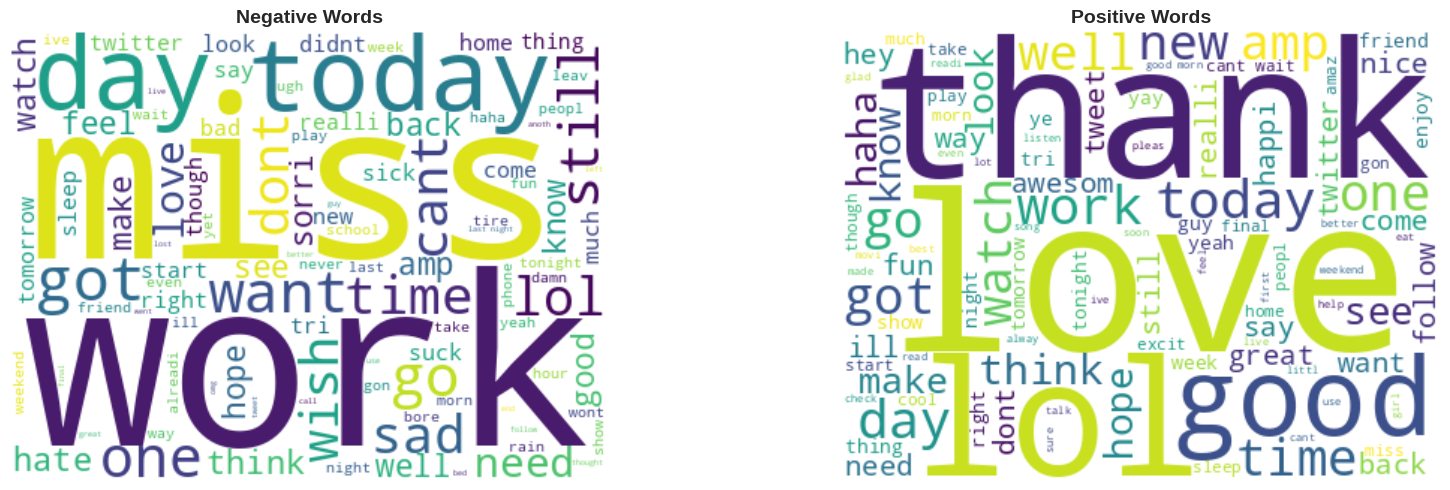

In [131]:
fig, axes = plt.subplots(1, len(labels), figsize=(18, 5))

for idx, sentiment in enumerate(labels):
    text = ' '.join(df_sample[df_sample['label'] == sentiment]['cleaned_text'])
    
    if len(text) > 0:
        wordcloud = WordCloud(width=400, height=300, background_color='white',
                              colormap='viridis', max_words=100).generate(text)
        axes[idx].imshow(wordcloud, interpolation='bilinear')
        axes[idx].set_title(f'{sentiment.title()} Words', fontsize=14, fontweight='bold')
        axes[idx].axis('off')

    else:
        axes[idx].text(0.5, 0.5, 'No data', ha='center', va='center')
        axes[idx].set_title(f'{sentiment.title()} Words')

plt.tight_layout()
plt.show()

## 9. Error Analysis: Misclassified Examples

Examining 5 examples where the model got it wrong helps us understand:
- Ambiguous language
- Sarcasm or irony
- Mixed sentiments in one tweet

In [132]:
results = pd.DataFrame({
    'text': df_sample.iloc[y_test.index]['text'].values,
    'actual': y_test.values,
    'nb_predicted': nb_pred,
    'lr_predicted': lr_pred
})

errors = results[results['actual'] != results['lr_predicted']]

print("=" * 60)
print("MISCLASSIFIED EXAMPLES (Logistic Regression)")
print("=" * 60)

for i, row in errors.head(5).iterrows():
    print(f"\n📌 Example {i+1}:")
    print(f"   Text:     {row['text'][:120]}...")
    print(f"   Actual:   {row['actual']}")
    print(f"   Predicted: {row['lr_predicted']}")

print(f"\nTotal misclassified: {len(errors)} out of {len(results)} ({len(errors)/len(results)*100:.1f}%)")

MISCLASSIFIED EXAMPLES (Logistic Regression)

📌 Example 2:
   Text:     @dellvink Ohh ... yeah ...  Were you here for fallas? In case you miss Valencia check out some pics on our blog:  http:/...
   Actual:   positive
   Predicted: negative

📌 Example 5:
   Text:     I am rooting for the Magic just to make @chadjarnagin mad! ...
   Actual:   positive
   Predicted: negative

📌 Example 8:
   Text:     @CathrynMarie I had disabled my account for a couple of weeks...my mental hard drive crashed!  LOL!  ...
   Actual:   positive
   Predicted: negative

📌 Example 9:
   Text:     @tickrtapebailey WHAAAAAAA? btw i am doing RE too ...
   Actual:   negative
   Predicted: positive

📌 Example 18:
   Text:     @dustedkitty LMAO @ booty call #6   Get extra wild in memory of my freak days. Lol Now it's just me.  One of has to have...
   Actual:   negative
   Predicted: positive

Total misclassified: 2425 out of 9944 (24.4%)


## 10. Conclusion

### Best Performing Model
Based on F1-Score and overall metrics.

### Real-World Applications
1. **Customer Support** — Auto-prioritize negative feedback
2. **Brand Monitoring** — Track sentiment on social media in real-time
3. **Product Improvement** — Identify common complaints
4. **Marketing** — Auto-collect positive testimonials

### Limitations
- Sarcasm and context-dependent sentiment remain challenging
- Could improve with deep learning (LSTM, BERT)
- Larger diverse dataset would improve generalization

In [133]:
best_model = "Logistic Regression" if lr_metrics[3] >= nb_metrics[3] else "Naive Bayes"
best_f1 = max(lr_metrics[3], nb_metrics[3])

print("=" * 60)
print("CONCLUSION")
print("=" * 60)
print(f"🏆 Best Model: {best_model}")
print(f"   F1-Score: {best_f1:.4f}")
print(f"\n🌍 Real-World Use Cases:")
print(f"   1. Auto-classify customer reviews by sentiment")
print(f"   2. Monitor brand reputation on social media")
print(f"   3. Prioritize negative feedback for immediate response")
print(f"   4. Generate positive review highlights for marketing")

# Save results
results.to_csv('/kaggle/working/sentiment_predictions.csv', index=False)
print(f"\n✅ Predictions saved to /kaggle/working/sentiment_predictions.csv")

CONCLUSION
🏆 Best Model: Logistic Regression
   F1-Score: 0.7560

🌍 Real-World Use Cases:
   1. Auto-classify customer reviews by sentiment
   2. Monitor brand reputation on social media
   3. Prioritize negative feedback for immediate response
   4. Generate positive review highlights for marketing

✅ Predictions saved to /kaggle/working/sentiment_predictions.csv
